## Calculating NINO3, NINO4, NINO34 from DCPP (the CMIP ones)

In [1]:
import numpy as np
import xarray as xr
import glob
import re
import matplotlib.pyplot as plt
from functools import partial

In [28]:
client.close()

In [2]:
from dask.distributed import Client
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33769,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40965,Total threads: 1
Dashboard: /proxy/39835/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:40365,


In [31]:
def dcpp_tropical_nino34(ds,coords):
    ds = ds.drop_vars('time') # Gets in the way of concatenation
    return ds.tos.where((np.abs(ds[coords[1]]).compute()<=5)
                        & ((ds[coords[0]]%360).compute()<=240)
                        & ((ds[coords[0]]%360).compute()>=190)
                        ).mean(coords[2:4]).rename('nino34')
    

In [36]:
out_dir = '/g/data/x77/jj8842/ENSO ROM/rom_decadal/indices/'

DCPP_dir = '/g/data/oi10/replicas/CMIP6/DCPP/'

filepaths = {#'CESM1-CAM5':'NCAR/CESM1-1-CAM5-CMIP5/dcppA-hindcast/s{Y}-r{M}i1p1f1/Omon/{var}/gn/{version}/{filename}',
            #'CanESM5':'CCCma/CanESM5/dcppA-hindcast/s{Y}-r{M}i1p2f1/Omon/{var}/gn/{version}/{filename}',
            'EC-Earth3':'EC-Earth-Consortium/EC-Earth3/dcppA-hindcast/s{Y}-r{M}i1p1f1/Omon/{var}/gr/{version}/{filename}',
            'IPSL-CM6A-LR':'IPSL/IPSL-CM6A-LR/dcppA-hindcast/s{Y}-r{M}i1p1f1/Omon/{var}/gn/{version}/{filename}',
            'MIROC6':'MIROC/MIROC6/dcppA-hindcast/s{Y}-r{M}i1p1f1/Omon/{var}/gn/{version}/{filename}',
            }

coord_names = {'CESM1-CAM5':('lon','lat','nlon','nlat'),
            'CanESM5':('longitude','latitude','i','j'),
            'EC-Earth3':('lon','lat','lon','lat'), # Using the regular grid version because I know it's a funky grid in some ways
            'IPSL-CM6A-LR':('nav_lon','nav_lat','x','y'),
            'MIROC6':('longitude','latitude','x','y'),
            }
var = 'tos'

for model in filepaths:
    ensemble_members = {}

    # Find start years
    d = DCPP_dir+'/'.join(filepaths[model].split('/')[:4])
    matching_paths = glob.glob(d.format(M='1',Y='*'))
    regex = re.compile(d.format(M='1',Y='(.*)'))
    Y = sorted(np.array(regex.findall('\n'.join(matching_paths)),'int'))

    # Find number of ensemble members
    d = DCPP_dir+'/'.join(filepaths[model].split('/')[:4])
    matching_paths = glob.glob(d.format(M='*',Y=Y[0]))
    regex = re.compile(d.format(M='(.*)',Y=Y[0]))
    M = sorted(np.array(regex.findall('\n'.join(matching_paths)),'int'))

    giant_filepath_list = []
    for y in Y:
        medium_filepath_list = []
        for m in M:

            # Pick out a single version:
            d = DCPP_dir+'/'.join(filepaths[model].split('/')[:8])
            matching_paths = glob.glob(d.format(var=var,M=m,Y=y,version='*'))
            regex = re.compile(d.format(var=var,M=m,Y=y,version='(.*)'))
            v = sorted(regex.findall('\n'.join(matching_paths)))
            v = v[-1]

            # Go find appropriate filenames
            d = DCPP_dir+'/'.join(filepaths[model].split('/'))
            matching_paths = glob.glob(d.format(var=var,M=m,Y=y,version=v,filename='*'))
            medium_filepath_list.append(sorted(matching_paths))
            
        giant_filepath_list.append(medium_filepath_list)
    #print(xr.open_mfdataset(giant_filepath_list[0][0]).data_vars)
    
    ds = xr.open_mfdataset(giant_filepath_list,
              combine = 'nested',
              concat_dim = ['Y','M','time'],
              parallel = True,
              chunks = {'i':-1,'j':-1,'x':-1,'y':-1,
                        'nlat':-1,'nlon':-1,'time':-1}, # xarray doesn't seem to care about overprescribing chunks
              preprocess = partial(dcpp_tropical_nino34, coords=coord_names[model]),
              ).assign_coords({'M':M,'Y':Y}).load()

    
    ds.to_netcdf(out_dir+model+'_DCPP_nino34.nc')                         

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 22.08 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [35]:
xr.open_mfdataset(giant_filepath_list[0][0])

/jobfs/164104426.gadi-pbs/ipykernel_1116745/1018568353.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  xr.open_mfdataset(giant_filepath_list[0][0])


<xarray.Dataset> Size: 140MB
Dimensions:    (time: 132, lat: 256, lon: 512, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1960-11-16 ... 1971-10-16T12:00:00
  * lat        (lat) float64 2kB -89.46 -88.77 -88.07 ... 88.07 88.77 89.46
  * lon        (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
Dimensions without coordinates: bnds
Data variables:
    tos        (time, lat, lon) float64 138MB dask.array<chunksize=(1, 256, 512), meta=np.ndarray>
    time_bnds  (time, bnds) datetime64[ns] 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 541kB dask.array<chunksize=(12, 256, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 1MB dask.array<chunksize=(12, 512, 2), meta=np.ndarray>
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               DCPP
    branch_method:             no parent
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     0.0
    ...                        ...
    variant_info:              Atmosphere initialization based on full-fields...
    sub_experiment_id:         s1960
    history:                   Wed Aug  5 17:46:35 2020: ncap2 -s tos=tos-273...
    nominal_resolution:        100 km
    sub_experiment:            initialized near end of year 1960
    NCO:                       netCDF Operators version 4.9.2 (Homepage = htt...

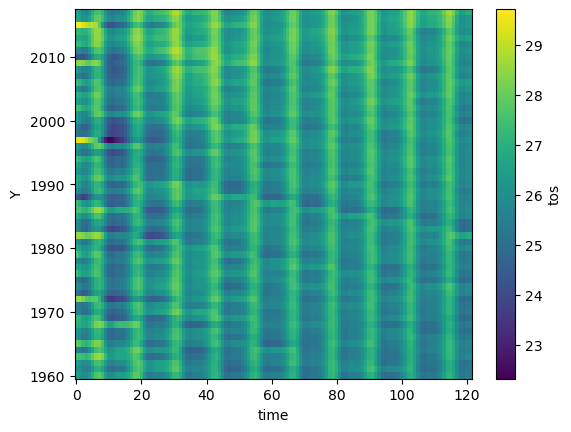

In [30]:
ds.mean('M').plot()

In [117]:
d = DCPP_dir+'/'.join(filepaths[model].split('/')[:8])
matching_paths = glob.glob(d.format(var=var,M=m,Y=y,version='*'))
regex = re.compile(d.format(var=var,M=m,Y=y,version='(.*)'))
v = sorted(regex.findall('\n'.join(matching_paths)))

In [123]:
d.format(var=var,M=m,Y=y,version='*')

'/g/data/oi10/replicas/CMIP6/DCPP/EC-Earth-Consortium/EC-Earth3/dcppA-hindcast/s1960-r1i1p1f1/Omon/dcppA/gn/*'

In [126]:
m

10

In [127]:
y

2018

In [119]:
matching_paths

[]

In [113]:
m,y

(1, 1960)

In [114]:
d

'/g/data/oi10/replicas/CMIP6/DCPP/EC-Earth-Consortium/EC-Earth3/dcppA-hindcast/s{Y}-r{M}i1p1f1/Omon/dcppA/gn/{version}'

In [ ]:

    # # Find number of start years
    # matching_paths = glob.glob((DCPP_dir+filepaths[model]).format(var=var,M='1',Y='*'))
    #     regex = re.compile(filepaths[model].format(var=var,M='(.*)'))
    #     ensemble_members[var] = regex.findall('\n'.join(matching_paths))

    #     if model == 'CESM2':
    #         # Minor quirk of the way files seem to be named
    #         ensemble_members = [m.replace('r','') for m in ensemble_members]


    #             # Find number of versions
    # consistent_crap = {'var':var,'M':'1','Y':'2000','filepath':''}
    # matching_paths = glob.glob((DCPP_dir+filepaths[model]).format(version='*',**consistent_crap))
    # regex = re.compile(filepaths[model].format(var=var,M='(.*)'))

    # # Throw out any where we don't have both tos and z20
    # shared_ensemble_members = [m for m in ensemble_members[variables[0]] if m in ensemble_members[variables[1]]] # List comprehension is eldrich
    # argsort = np.argsort(np.array(shared_ensemble_members,float))
    # shared_ensemble_members = np.array(shared_ensemble_members)[argsort]

    # shared_filepaths = [[(MMLEA_dir+filepaths[model]).format(var=var,M=m) for m in shared_ensemble_members]for var in variables]


In [5]:
miroc6_nino34 = xr.load_dataarray('/g/data/x77/jj8842/ENSO ROM/indices/MIROC6_DCPP_T.nc')

In [18]:
import sys
sys.path.append('/g/data/x77/jj8842/ENSO ROM/rom_decadal/')
import rom_decadal_lib as rdl

<Figure size 640x480 with 0 Axes>

In [68]:
def declim_dcpp(da):
    gp = da.time%12
    return da.groupby(gp)-da.groupby(gp).mean().mean(('M','Y'))

In [25]:
miroc6_nino34.mean('M')

<xarray.DataArray 'tos' (Y: 62, time: 122)> Size: 30kB
array([[24.642736, 24.536137, 24.682379, ..., 25.13201 , 24.995344,
        25.23313 ],
       [24.54217 , 24.337608, 24.540636, ..., 25.71619 , 25.737295,
        25.918402],
       [24.612612, 24.652058, 24.892538, ..., 25.740778, 25.63808 ,
        25.477568],
       ...,
       [25.704306, 25.433903, 25.398602, ..., 25.626608, 25.657598,
        25.719208],
       [24.51685 , 24.39438 , 24.937756, ..., 25.660223, 25.654911,
        25.804514],
       [24.595509, 24.489542, 24.746971, ..., 26.218029, 26.091839,
        26.205515]], dtype=float32)
Coordinates:
  * Y        (Y) int64 496B 1960 1961 1962 1963 1964 ... 2018 2019 2020 2021
Dimensions without coordinates: time

In [31]:
def dedrift(da):
    return da - da.mean('Y')

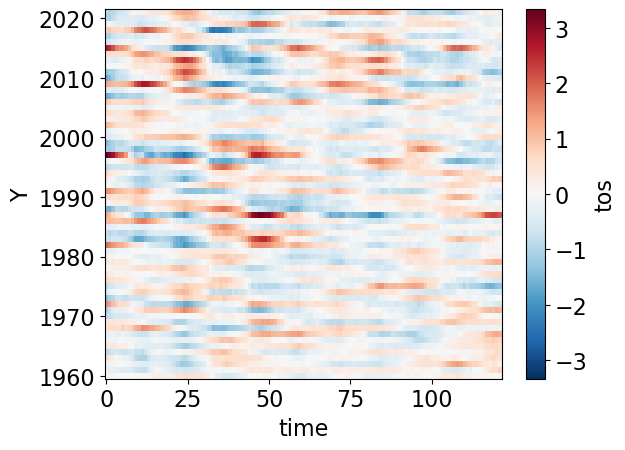

In [36]:
dedrift(declim_dcpp(miroc6_nino34.mean('M')).drop_vars('time')).plot()

In [44]:
def detrend_quadratic_dcpp(y):
    y = y.transpose('Y','time',)
    if len(y.shape)>1:
        meany = np.mean(y,axis=1)
    else:
        meany = y
        
    x = np.arange(y.shape[0])
    c = np.polyfit(x,meany,deg=2)
    return y-np.expand_dims((x**2*c[0]+x*c[1]+c[2]),-1)

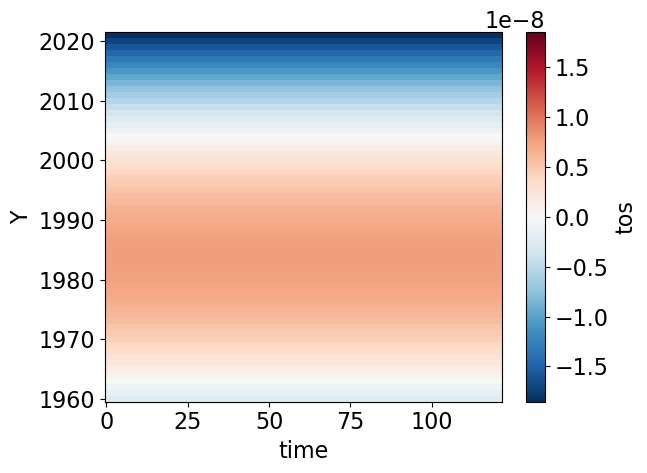

In [45]:
(detrend_quadratic_dcpp(
    dedrift(declim_dcpp(miroc6_nino34.mean('M')).drop_vars('time')
           )
)-dedrift(declim_dcpp(miroc6_nino34.mean('M')).drop_vars('time')
           )).plot()

In [70]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da-fit

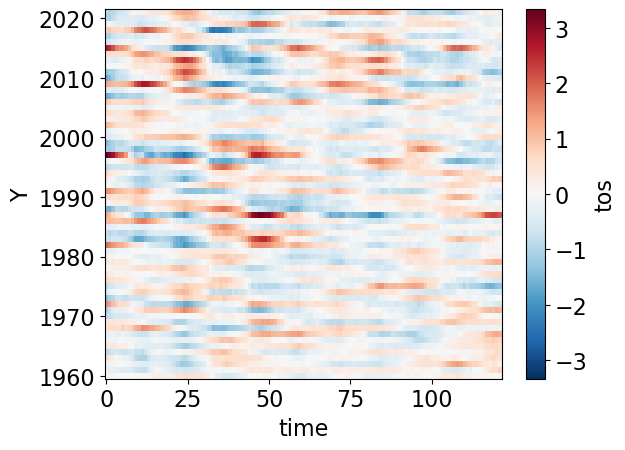

In [53]:
dedrift(declim_dcpp(miroc6_nino34.mean('M')).drop_vars('time')).plot()

In [71]:
detrend_dim(dedrift(declim_dcpp(miroc6_nino34.mean('M')).drop_vars('time')),'Y').plot()

ValueError: 'M' not found in array dimensions ('Y', 'time')

In [56]:
def get_ACC(x):
    x = x.transpose('M',...)
    r = xr.ones_like(x.isel(Y=0))*np.nan
    for i,m in enumerate(x.M):
        not_m = xr.ones_like(x.M,dtype=bool)
        not_m[i] = False

        r[i] = xr.corr(x.sel(M=m),x.sel(M=not_m).mean('M'),'Y')
    return r

In [ ]:
# Note, when you subtracted a monthly cycle from each run indicvidually it helped?

(0.0, 1.0)

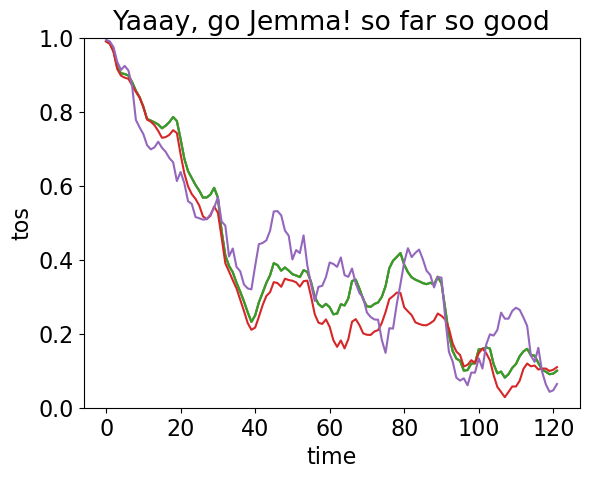

In [79]:
get_ACC(miroc6_nino34).mean('M').plot()
get_ACC(dedrift(miroc6_nino34)).mean('M').plot()
get_ACC(declim_dcpp(miroc6_nino34).drop_vars('time')).mean('M').plot()

get_ACC(declim_dcpp(miroc6_nino34.sel(Y=slice(None,2010))).drop_vars('time')).mean('M').plot()
get_ACC(declim_dcpp(miroc6_nino34.sel(Y=slice(2010,None))).drop_vars('time')).mean('M').plot()


plt.title('Yaaay, go Jemma! so far so good')
plt.ylim(0,1)

In [67]:
da = miroc6_nino34
gp = da.time%12
da.groupby(gp).mean()

<xarray.DataArray 'tos' (M: 10, Y: 62, time: 12)> Size: 30kB
array([[[25.50332 , 25.5832  , 25.7831  , ..., 26.06395 , 25.649792,
         25.647388],
        [25.193092, 25.246294, 25.448034, ..., 25.80782 , 25.403091,
         25.356356],
        [25.306053, 25.31849 , 25.617798, ..., 26.103308, 25.650322,
         25.524231],
        ...,
        [26.015188, 25.944715, 26.236773, ..., 26.680122, 26.18412 ,
         26.053709],
        [26.276613, 26.364151, 26.44199 , ..., 26.836948, 26.47875 ,
         26.398901],
        [26.058258, 26.059673, 26.435411, ..., 26.26831 , 26.052279,
         26.155811]],

       [[25.10265 , 25.188543, 25.474525, ..., 25.800167, 25.379358,
         25.247189],
        [25.151022, 25.18622 , 25.530945, ..., 25.698898, 25.361586,
         25.26351 ],
        [25.435373, 25.547445, 25.53355 , ..., 25.890621, 25.55417 ,
         25.509045],
...
        [25.879978, 25.995035, 26.358065, ..., 26.265915, 25.865124,
         25.866913],
        [26.0356  , 25.973948, 26.403975, ..., 26.523968, 26.128046,
         26.16235 ],
        [25.927423, 25.936804, 26.169388, ..., 26.462885, 26.099232,
         26.017548]],

       [[24.805208, 24.978018, 25.192036, ..., 25.342373, 24.982409,
         24.93475 ],
        [25.376312, 25.436848, 25.492235, ..., 25.968891, 25.517841,
         25.441229],
        [25.302242, 25.328724, 25.325415, ..., 25.861153, 25.542934,
         25.378195],
        ...,
        [26.279255, 26.283438, 26.419422, ..., 26.83481 , 26.500963,
         26.41453 ],
        [26.16158 , 26.115028, 26.551096, ..., 26.73933 , 26.293497,
         26.415592],
        [26.154266, 26.22422 , 26.438383, ..., 26.559875, 26.294556,
         26.270575]]], dtype=float32)
Coordinates:
  * M        (M) int64 80B 1 2 3 4 5 6 7 8 9 10
  * Y        (Y) int64 496B 1960 1961 1962 1963 1964 ... 2018 2019 2020 2021
  * time     (time) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11